<a href="https://colab.research.google.com/github/CeZa18/ITAI-1371-ML-Labs/blob/main/L12_CesarZaldivar_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 12 Lab - Ethics, Fairness, and Bias in ML
**Objective:** To understand how machine learning models can inherit and amplify societal biases, how to measure this bias using fairness metrics, and to think critically about the ethical implications of deploying ML systems.
**In this lab, you will train a model on a real-world dataset and audit it for fairness across different demographic groups.**

## Part 1: What is Algorithmic Bias?
**Concept:** Machine learning models learn from data. If the data reflects existing societal biases, the model will learn those biases. An "unbiased" algorithm trained on biased data will produce a biased model. This can lead to systems that are systematically unfair to certain groups of people.

**Sources of Bias:**
*   **Historical Bias:** The data reflects a world with historical injustices (e.g., past hiring data may show fewer women in leadership roles).
*   **Measurement Bias:** The way we collect or measure data is flawed (e.g., using arrest records as a proxy for crime, which can be influenced by policing patterns).
*   **Representation Bias:** The data underrepresents certain groups, so the model doesn't learn to perform well for them.

**Problem:** We will use the "Adult" dataset, which is used to predict whether an individual's income is greater than $50k/year. It contains sensitive attributes like `sex` and `race`, which we can use to audit our model for bias.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load the data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, header=None, names=columns, sep=r',\s*', engine='python', na_values='?')

# Data Cleaning
df.dropna(inplace=True)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
X = df.drop('income', axis=1)
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create a preprocessing pipeline
numeric_features = X.select_dtypes(include='number').columns
categorical_features = X.select_dtypes(exclude='number').columns
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
     (OneHotEncoder(handle_unknown='ignore'), categorical_features))

# Train a baseline model
model = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)
print(f"Overall model accuracy: {model.score(X_test, y_test):.2%}")

Overall model accuracy: 84.61%


## Part 2: Auditing the Model for Fairness
High overall accuracy can hide poor performance on specific subgroups. We need to audit the model by comparing its performance across sensitive attributes like `sex`.

**Concept: Group Fairness**
One common fairness goal is to ensure the model works equally well for different groups. We can measure this by calculating metrics for each group separately.

**Your Task:** Create a function to calculate accuracy for different subgroups and then use it to compare the model's performance for males and females.

In [2]:
# --- ENTER YOUR CODE HERE ---
def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
  """Calculates accuracy for a specific subgroup of the test data."""
  # 1. Create a boolean mask to select the subgroup from X_test
  subgroup_mask = X_test[subgroup_column] == subgroup_value

  # 2. Select the subgroup data
  X_subgroup = X_test[subgroup_mask]
  y_subgroup = y_test[subgroup_mask]

  # 3. Calculate and return the model's score on this subgroup
  return model.score(X_subgroup, y_subgroup)

# --- Main / Execution Block ---

# 4. Calculate accuracy for males and females
acc_male = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Male')
acc_female = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Female')

# 5. Print the results
print(f"Accuracy for Males: {acc_male:.2%}")
print(f"Accuracy for Females: {acc_female:.2%}")

Accuracy for Males: 81.20%
Accuracy for Females: 91.81%


### Task 2: Deeper Dive with a Confusion Matrix
Accuracy alone doesn't tell the whole story. Let's look at the types of errors the model makes for each group.

**Your Task:** Calculate and compare the **False Positive Rate (FPR)** and **False Negative Rate (FNR)** for males and females.
*   **FPR:** `FP / (FP + TN)` - The percentage of people who did NOT have high income but were incorrectly predicted to have high income.
*   **FNR:** `FN / (FN + TP)` - The percentage of people who DID have high income but were incorrectly predicted to have low income.

In [3]:
from sklearn.metrics import confusion_matrix
def get_rates(model, X_test, y_test, subgroup_column, subgroup_value):
  subgroup_mask = X_test[subgroup_column] == subgroup_value
  X_subgroup = X_test[subgroup_mask]
  y_subgroup = y_test[subgroup_mask]
  y_pred_subgroup = model.predict(X_subgroup)
  tn, fp, fn, tp = confusion_matrix(y_subgroup, y_pred_subgroup).ravel()
  fpr = fp / (fp + tn)
  fnr = fn / (fn + tp)
  return fpr, fnr

# --- ENTER YOUR CODE HERE ---
# 1. Calculate the rates for males and females
fpr_male, fnr_male = get_rates(model, X_test, y_test, 'sex', 'Male')
fpr_female, fnr_female = get_rates(model, X_test, y_test, 'sex', 'Female')
print(f"Male - False Positive Rate: {fpr_male:.2%}, False Negative Rate: {fnr_male:.2%}")
print(f"Female - False Positive Rate: {fpr_female:.2%}, False Negative Rate: {fnr_female:.2%}")

Male - False Positive Rate: 10.26%, False Negative Rate: 37.80%
Female - False Positive Rate: 2.81%, False Negative Rate: 47.84%


Metric                               Male     Female
Accuracy                          81.20%    91.81%
False Positive Rate (FPR)         10.26%     2.81%
False Negative Rate (FNR)         37.80%    47.84%
True Positive Rate (TPR)          62.20%    52.16%

 TPR Fairness Gap: 10.04%  ❌ Significant disparity (gap > 10%)


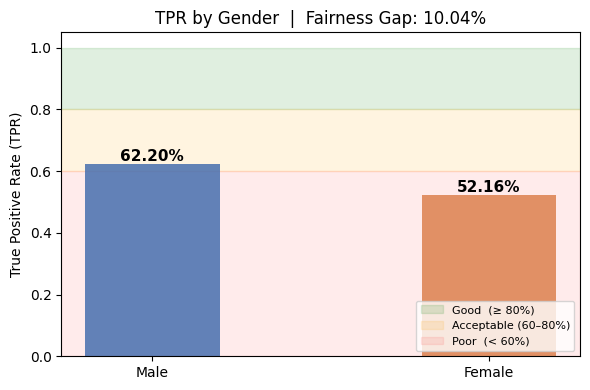

In [4]:
# ── FAIRNESS SUMMARY: TPR Comparison ─────────────────────────────────────────

'''
    Use the variables already defined above: acc_male, acc_female,
    fpr_male, fnr_male, fpr_female, fnr_female to comapre the TPR and
    evaluate the predicted model fairness
'''

import matplotlib.pyplot as plt

# 1. Calculate TPR from FNR (TPR = 1 - FNR)
tpr_male   = 1 - fnr_male
tpr_female = 1 - fnr_female
tpr_gap    = abs(tpr_male - tpr_female)

# 2. Print a simple comparison table
print("=" * 55)
print(f"{'Metric':<30} {'Male':>10} {'Female':>10}")
print("=" * 55)
print(f"{'Accuracy':<30} {acc_male:>9.2%} {acc_female:>9.2%}")
print(f"{'False Positive Rate (FPR)':<30} {fpr_male:>9.2%} {fpr_female:>9.2%}")
print(f"{'False Negative Rate (FNR)':<30} {fnr_male:>9.2%} {fnr_female:>9.2%}")
print(f"{'True Positive Rate (TPR)':<30} {tpr_male:>9.2%} {tpr_female:>9.2%}")
print("=" * 55)
print(f"\n TPR Fairness Gap: {tpr_gap:.2%}", end="  ")
if tpr_gap <= 0.05:
    print("✅ Fair (gap ≤ 5%)")
elif tpr_gap <= 0.10:
    print("⚠️  Moderate disparity (5–10%)")
else:
    print("❌ Significant disparity (gap > 10%)")

# 3. Simple bar chart — TPR by group with rating bands
fig, ax = plt.subplots(figsize=(6, 4))

# Shaded rating bands (background)
ax.axhspan(0.80, 1.00, color="green",  alpha=0.12, label="Good  (≥ 80%)")
ax.axhspan(0.60, 0.80, color="orange", alpha=0.12, label="Acceptable (60–80%)")
ax.axhspan(0.00, 0.60, color="red",    alpha=0.08, label="Poor  (< 60%)")

# Bars
bars = ax.bar(["Male", "Female"], [tpr_male, tpr_female],
              color=["#4C72B0", "#DD8452"], width=0.4, alpha=0.88)

# Value labels on bars
for bar, val in zip(bars, [tpr_male, tpr_female]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2%}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.05)
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title(f"TPR by Gender  |  Fairness Gap: {tpr_gap:.2%}")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 📝 Reflective Knowledge Check
**Instructions:** Answer the following questions in this markdown cell. Your answers should be based on **your specific results** from the code you ran above.
1.  **Analyze Your Results:** Look at the subgroup accuracies you calculated. Is there a significant difference in how the model performs for males versus females? Which group does the model perform better for?
2.  **Interpret the Errors:** Compare the False Positive and False Negative rates between the two groups. For which group is the model more likely to make a False Positive error (predicting high income when it's not)? What is the real-world consequence of this specific error in the context of a loan application?
3.  **Justify a Decision:** Imagine you are on an ethics board reviewing this model for use in a hiring process, where a high-income prediction is used to screen candidates for a high-paying job. Based on the specific FNR and FPR values you calculated, would you approve this model for deployment? Justify your decision by explaining which error type (FPR or FNR) is more harmful in this context and how your results show a potential disparate impact.
4.  **Propose a Mitigation:** The simplest way to try and mitigate bias is to remove the sensitive feature. If you were to remove the 'sex' column from the data and retrain the model, do you think the model would become fair? Why or why not? (Hint: Think about what other columns might be correlated with 'sex').

**[ENTER YOUR ANSWERS HERE]**

1. By looking at the model accuracy for each of the *female* and *male* subgroups, at first glance it looks like the model is more accurate for the *female* group with a **91.81%** accuracy vs **81.20%**. A difference of over **10%** seems significant to think that the model favors the **female** group.
2. By running the **TPR Fairness Comparison** we are able to make more sense of the overall metrics. We can observe that for both groups the TPR is below **70%**, meaning that in the context of a real-world loan application scenario this model would miss a significant portion of the creditworthy applicants in both groups.
3. My decision would be **NOT** to approve this model. The reason is that a qualified person would be screened out of the hiring process. Thus, making a _False Negative_ (FNR) more harmful. Specifically, the FNR for the **female** group is 47.84% compared to 37.80% for the **male** group, meaning qualified **female** candidates are screened out at a disproportionately higher rate. High overall accuracy doesn't mean the model is fair in this context.
4. The proposed pipeline mitigation by suppressing the `'sex'` column known as **"Fairness Through Unawareness"** might sound logical; however, often times naive and insufficient. The reason is that there are several columns that are statistically correletaed with `'sex'`— such as: `'marital-status'` or `'relationship'` — meaning the model can reconstruct gender patterns, which by proxy would recreate the bias.